In [40]:
import os
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
folder = '/srv/seolab/srai/tropicalPacifiTemperatureBudget/WPWP_GLORYS_data/'

start_date = datetime(2018, 1, 1)
end_date   = datetime(2019, 6, 29)

# longitude window (degrees, likely 0–360 on GLORYS)
LON_MIN = 125.0
LON_MAX = 250.0

# latitude to sample (choose 0 for equator; change if needed)
LAT_TARGET = 0.0

# ----------------------------
# HELPERS
# ----------------------------
def date_list(d0, d1):
    n = (d1 - d0).days + 1
    return [d0 + timedelta(days=i) for i in range(n)]

def open_flux_path(d):
    return os.path.join(folder, f'GLORYS12v1_dailyAvg_trendWithFluxes_{d:%Y-%m-%d}.nc')

def open_var_path(d):
    return os.path.join(folder, f'GLORYS12v1_dailyAvg_{d:%Y-%m-%d}.nc')

# ----------------------------
# INITIAL METADATA READ (to get lat/lon & indices)
# ----------------------------
first_vars = xr.open_dataset(open_var_path(start_date))
lat = first_vars['latitude'].values
lon = first_vars['longitude'].values

# nearest latitude index to LAT_TARGET
lat_index = int(np.argmin(np.abs(lat - LAT_TARGET)))

# longitude slice indices
lon_idx_start = int(np.argmin(np.abs(lon - LON_MIN)))
lon_idx_end   = int(np.argmin(np.abs(lon - LON_MAX)))

# depth index

depthIndex = 2

# ensure start <= end (no wrap handling needed for 160E–220E on 0–360 grid)
if lon_idx_start > lon_idx_end:
    lon_idx_start, lon_idx_end = lon_idx_end, lon_idx_start

# keep a copy of lon subset for plotting
lon_sub = lon[lon_idx_start:lon_idx_end + 1]

first_vars.close()

# ----------------------------
# GATHER DAILY SLICES
# ----------------------------
temps = []       # list of arrays with shape (nx,)
trend = []     # list of arrays with shape (nx,)
east = []      # list of arrays with shape (nx,)
west = []      # list of arrays with shape (nx,)
north = []      # list of arrays with shape (nx,)
south = []      # list of arrays with shape (nx,)
horiz = []      # list of arrays with shape (nx,)
vert = []      # list of arrays with shape (nx,)
total = []      # list of arrays with shape (nx,)
dates = []       # for plotting / reference

for d in date_list(start_date, end_date):
    if d.day == 1:
        print(f'processing month {d:%Y-%m}')

    var_path = open_var_path(d)
    flux_path = open_flux_path(d)

    if not (os.path.exists(var_path) and os.path.exists(flux_path)):
        # skip missing days
        continue

    ds_vars  = xr.open_dataset(var_path)
    ds_flux  = xr.open_dataset(flux_path)

    try:
        # Select surface (depth=depthIndex), chosen latitude, lon slice, and first (only) time
        # Shapes: (time=1, lon_slice) -> squeeze to (lon_slice,)
        T = ds_vars['thetao'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                   longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        trend_thetao = ds_flux['trend_thetao'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                   longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        east_flux = ds_flux['thetao_flux_east'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        west_flux = ds_flux['thetao_flux_west'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        north_flux = ds_flux['thetao_flux_north'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        south_flux = ds_flux['thetao_flux_south'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        horiz_flux = ds_flux['thetao_flux_horiz'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        vert_flux = ds_flux['thetao_flux_vert'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        total_flux = ds_flux['thetao_flux_total'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values

        temps.append(T)
        trend.append(trend_thetao)
        east.append(east_flux)
        west.append(west_flux)
        north.append(north_flux)
        south.append(south_flux)
        horiz.append(horiz_flux)
        vert.append(vert_flux)
        total.append(total_flux)
        dates.append(d)
    finally:
        ds_vars.close()
        ds_flux.close()


processing month 2018-01
processing month 2018-02
processing month 2018-03
processing month 2018-04
processing month 2018-05
processing month 2018-06
processing month 2018-07
processing month 2018-08
processing month 2018-09
processing month 2018-10
processing month 2018-11
processing month 2018-12
processing month 2019-01
processing month 2019-02
processing month 2019-03
processing month 2019-04
processing month 2019-05
processing month 2019-06


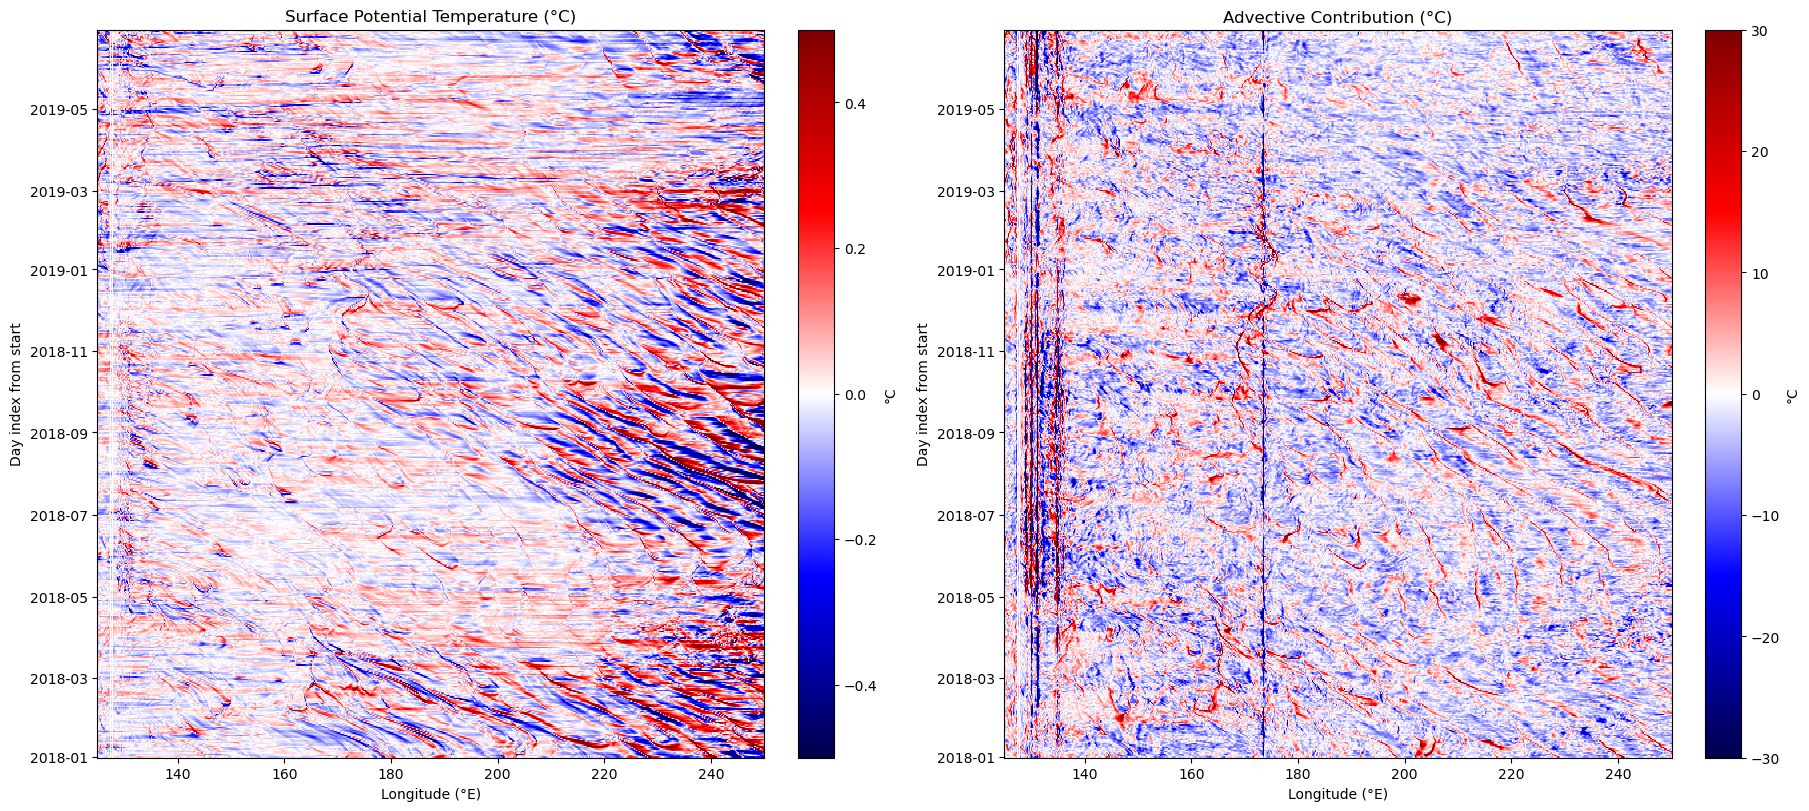

In [46]:
advection = np.array(total).copy()
horiz = np.array(horiz).copy()
east_west = np.array(east).copy()+ np.array(west).copy()
north_south = np.array(north).copy()+ np.array(south).copy()
temp = np.array(temps).copy()
temp_trend = np.array(trend).copy()
# ----------------------------
# PLOTTING
# ----------------------------
fig, axes = plt.subplots(ncols=2, figsize=(18, 8), constrained_layout=True)
cmap = plt.cm.seismic
vmin, vmax = 28.0, 29.0
vmin, vmax = -0.5, 0.5
# x-axis as longitude indices (or degrees). Using degrees is clearer:
X = lon_sub  # shape (nx,)
Y = np.arange(temp.shape[0])  # day index

# Plot temperature
im0 = axes[0].pcolormesh(X, dates, temp_trend*24*3600, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
axes[0].set_title('Surface Potential Temperature (°C)')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Day index from start')
fig.colorbar(im0, ax=axes[0], label='°C')

vmin, vmax = -30, 30
# Plot advective-only reconstruction
im1 = axes[1].pcolormesh(X, dates, advection*24*3600, cmap=cmap,  vmin=vmin, vmax=vmax, shading='auto')
axes[1].set_title('Advective Contribution (°C)')
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Day index from start')
fig.colorbar(im1, ax=axes[1], label='°C')

In [42]:
from scipy.signal import convolve



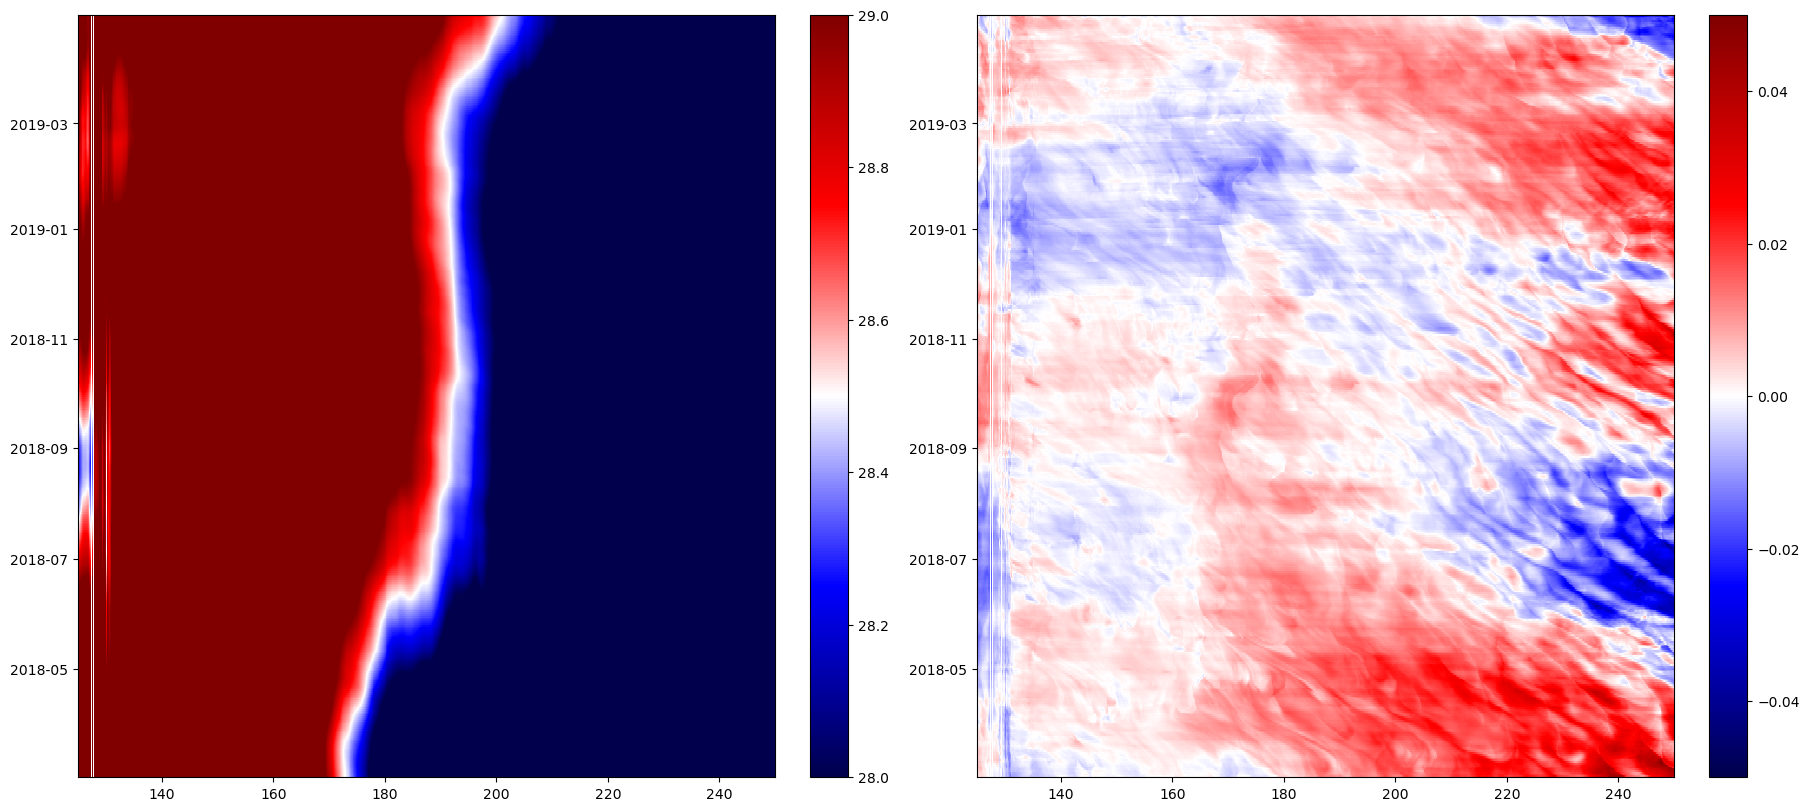

In [50]:
klen = 121
hklen = int(klen//2)
kernel = np.ones((klen,1))
kernel /= np.sum(kernel)
dtT = convolve(temp_trend, kernel, mode='valid')
T = convolve(temp, kernel, mode='valid')

fig, axes = plt.subplots(ncols=2, figsize=(18, 8), constrained_layout=True)

ax = axes[0]
vmin, vmax = 28, 29
pmesh = ax.pcolormesh(X, dates[hklen:-hklen], T, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)

ax = axes[1]
vmin, vmax = -0.05, 0.05
pmesh = plt.pcolormesh(X, dates[hklen:-hklen], dtT*24*3600, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)

In [45]:
ds_flux

<xarray.Dataset>
Dimensions:             (time: 1, depth: 28, latitude: 385, longitude: 2245)
Coordinates:
  * time                (time) datetime64[ns] 2019-06-29T12:00:00
  * depth               (depth) float32 0.494 1.541 2.646 ... 186.1 222.5 266.0
  * latitude            (latitude) float32 -16.0 -15.92 -15.83 ... 15.92 16.0
  * longitude           (longitude) float32 109.0 109.1 109.2 ... 295.9 296.0
Data variables: (12/21)
    trend_thetao        (time, depth, latitude, longitude) float64 ...
    tend_so             (time, depth, latitude, longitude) float64 ...
    thetao_flux_horiz   (latitude, longitude, time, depth) float64 ...
    thetao_flux_vert    (time, depth, latitude, longitude) float64 ...
    thetao_flux_total   (latitude, longitude, time, depth) float64 ...
    thetao_flux_east    (latitude, longitude, time, depth) float64 ...
    ...                  ...
    so_flux_west        (latitude, longitude, time, depth) float64 ...
    so_flux_north       (latitude, longitude, time, depth) float64 ...
    so_flux_south       (latitude, longitude, time, depth) float64 ...
    so_flux_bottom      (time, depth, latitude, longitude) float64 ...
    so_flux_top         (time, depth, latitude, longitude) float64 ...
    dVol                (time, depth, latitude, longitude) float64 ...

In [ ]:
fluxes_ds